In [1]:
import os, glob, sys
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from fancyimpute import IterativeImputer

## Load all the data so we can explore it. 
testing_file = 'SEPSISdat_test.pickle'
training_file = 'SEPSISdat_train.pickle'
if os.path.isfile(training_file):
  SEPSISdat_train = pd.DataFrame.from_dict(pd.read_pickle(training_file))
print(len(SEPSISdat_train)) # should be n=2138

if os.path.isfile(testing_file):
  SEPSISdat_test = pd.DataFrame.from_dict(pd.read_pickle(testing_file))
print(len(SEPSISdat_test)) # should be n=540

cat_feats = ['sex_adm', 'spo2onoxy_adm','respdistress_adm','caprefill_adm','bcseye_adm','bcsmotor_adm',
             'bcsverbal_adm', 'bcgscar_adm', 'vaccmeasles_adm', 'vaccpneumoc_adm', 'vaccdpt_adm', 
             'priorweekabx_adm', 'priorweekantimal_adm', 'symptoms_adm_rash', 'symptoms_adm_cough', 
             'symptoms_adm_cough_chronic', 'symptoms_adm_diarrhea', 'symptoms_adm_diarrhea_chronic', 
             'symptoms_adm_fever', 'symptoms_adm_fever_chronic', 'symptoms_adm_vomiting', 'symptoms_adm_sleepy', 
             'symptoms_adm_edemafeet', 'symptoms_adm_urinecolor', 'symptoms_adm_oliguria', 'symptoms_adm_bloodstool', 
             'symptoms_adm_seizures', 'symptoms_adm_jaundice', 'comorbidity_adm_airway', 'comorbidity_adm_cardiac', 
             'comorbidity_adm_sicklecell', 'comorbidity_adm_tuberculosis', 'comorbidity_adm_disability', 
             'priorhosp_adm', 'prioryearwheeze_adm', 'prioryearcough_adm', 'diarrheaoften_adm', 'tbcontact_adm', 
             'feedingstatus_adm', 'birthdetail_adm_premature', 'travelmethod_adm', 'traveldist_adm', 
             'badhealthduration_adm', 'waterpure_adm', 'cookloc_adm', 'lightfuel_adm', 'tobacco_adm', 
             'bednet_adm', 'hctpretransfusion_adm', 'hivstatus_adm', 'malariastatuspos_adm'
            ]
labelencoder = LabelEncoder()

for col in cat_feats:
    SEPSISdat_train[col] = labelencoder.fit_transform(SEPSISdat_train[col])
    SEPSISdat_train[col] = SEPSISdat_train[col].astype('int')
    SEPSISdat_test[col] = labelencoder.fit_transform(SEPSISdat_test[col])
    SEPSISdat_test[col] = SEPSISdat_test[col].astype('int')

2138
540


/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: R

[LightGBM] [Info] Number of positive: 89, number of negative: 2049
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1861
[LightGBM] [Info] Number of data points in the train set: 2138, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.041628 -> initscore=-3.136471
[LightGBM] [Info] Start training from score -3.136471
AUC: 0.997
AUC_test: 0.806
Threshold: 0.1097
{'AUC': np.float64(0.997), 'AUPRC': np.float64(0.951), 'Net Benefit': np.float64(0.037), 'ECE': np.float64(0.0456), 'tp': np.float64(87.0), 'fp': np.float64(65.0), 'fn': np.float64(2.0), 'tn': np.float64(1984.0), 'F1': np.float64(0.722), 'Sensitivity': np.float64(0.978), 'Specificity': np.float64(0.968), 'Inference Speed': 0, 'Weighted Score': np.float64(0.79)}
{'AUC': np.float64(0.806), 'AUPRC': np

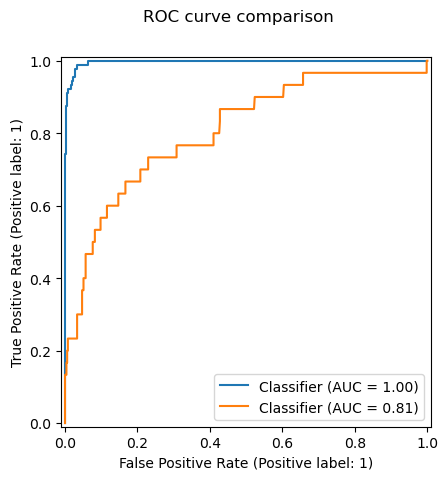

In [2]:
#### OPTION 1: BOOSTED TREE #####
SEPSISdat_train_values = SEPSISdat_train.drop(columns='inhospital_mortality', axis=1)
SEPSISdat_test_values = SEPSISdat_test.drop(columns='inhospital_mortality', axis=1)

## Substitute missing values
imputer = IterativeImputer()
#
SEPSISdat_train_values_imp = pd.DataFrame(imputer.fit_transform(SEPSISdat_train_values),columns=SEPSISdat_train_values.columns)
SEPSISdat_train_values = SEPSISdat_train_values_imp
#
SEPSISdat_test_values_imp = pd.DataFrame(imputer.fit_transform(SEPSISdat_test_values),columns=SEPSISdat_test_values.columns)
SEPSISdat_test_values = SEPSISdat_test_values_imp

## Add some derived variables, e.g. shock index= HR/SBP
SEPSISdat_train_values = SEPSISdat_train_values.assign(SI=SEPSISdat_train_values.hr_bpm_adm/SEPSISdat_train_values.sysbp_mmhg_adm)
SEPSISdat_test_values = SEPSISdat_test_values.assign(SI=SEPSISdat_test_values.hr_bpm_adm/SEPSISdat_test_values.sysbp_mmhg_adm)

## Build a LightGBM model using all the training data
import lightgbm as lgb
train_data = lgb.Dataset(data=SEPSISdat_train_values, label=SEPSISdat_train.inhospital_mortality)
param = {'objective': 'binary'}
bst = lgb.train(param, train_data, 10)

## Add the predictions 
SEPSISdat_train_values = SEPSISdat_train_values.assign(probSepsisGBM=bst.predict(data=SEPSISdat_train_values))
SEPSISdat_test_values = SEPSISdat_test_values.assign(probSepsisGBM=bst.predict(data=SEPSISdat_test_values))

## Quick but not necessarily great way to find a threshold. Also calculate the AUC
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisGBM)
fpr1, tpr1, thresholds1 = roc_curve(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisGBM)
train_disp=RocCurveDisplay.from_predictions(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisGBM)
test_disp=RocCurveDisplay.from_predictions(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisGBM, ax=train_disp.ax_)
train_disp.figure_.suptitle("ROC curve comparison")

print('AUC:',round(roc_auc_score(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisGBM),3))
print('AUC_test:',round(roc_auc_score(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisGBM),3))

# Save the model and get the threshold for use as a model
bst.save_model('lightgbm.model')
thresh=round(thresholds[np.argmax(tpr - fpr)],4)
print('Threshold:', thresh)

# Quick calculation of utility score
import evaluate_performance as ev
util = ev.evaluate_model(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisGBM,thresh,"Training",0)
print(util)
util_test = ev.evaluate_model(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisGBM,thresh,"Testing",0)
print(util_test)

/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


const= [-0.0001]
coeffs = np.array(
[[-2.100e-03 -8.000e-03 -1.000e-03  0.000e+00  2.200e-03  1.210e-02
   1.000e-04 -5.600e-03 -3.800e-03 -6.300e-03  0.000e+00  0.000e+00
   1.207e-01  2.280e-02  1.650e-02  0.000e+00 -3.000e-04 -6.000e-04
  -1.000e-04 -0.000e+00 -0.000e+00 -0.000e+00 -1.000e-04 -0.000e+00
  -0.000e+00 -1.000e-04 -1.000e-04 -2.000e-04 -2.000e-04 -1.000e-04
  -1.000e-04 -0.000e+00 -1.000e-04 -0.000e+00 -0.000e+00 -0.000e+00
  -1.000e-04 -0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00
  -0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00
  -0.000e+00 -0.000e+00 -0.000e+00 -3.000e-04 -0.000e+00 -0.000e+00
  -1.000e-04 -0.000e+00 -0.000e+00 -0.000e+00 -3.000e-04 -2.000e-04
  -4.000e-04 -1.000e-04 -1.000e-04 -4.000e-04 -2.000e-04 -0.000e+00
  -2.000e-04 -0.000e+00 -1.000e-04  0.000e+00]] )
AUC: 0.486
AUC_test: 0.493
thresh= 0.0311
{'AUC': np.float64(0.486), 'AUPRC': np.float64(0.041), 'Net Benefit': np.float64(0.013), 'ECE': np.float64(0.3145), 'tp': np

/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear

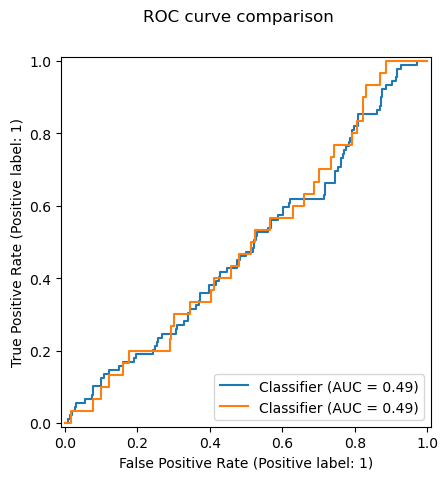

In [3]:
#### OPTION 2: LOGISTIC REGRESSION (this doesn't work correctly, so don't use it) ####
SEPSISdat_train_values = SEPSISdat_train.drop(columns='inhospital_mortality', axis=1)
SEPSISdat_test_values = SEPSISdat_test.drop(columns='inhospital_mortality', axis=1)

## Substitute missing values
imputer = IterativeImputer()
#
SEPSISdat_train_values_imp = pd.DataFrame(imputer.fit_transform(SEPSISdat_train_values),columns=SEPSISdat_train_values.columns)
SEPSISdat_train_values = SEPSISdat_train_values_imp
#
SEPSISdat_test_values_imp = pd.DataFrame(imputer.fit_transform(SEPSISdat_test_values),columns=SEPSISdat_test_values.columns)
SEPSISdat_test_values = SEPSISdat_test_values_imp

## Add some derived variables, e.g. shock index= HR/SBP
SEPSISdat_train_values = SEPSISdat_train_values.assign(SI=SEPSISdat_train_values.hr_bpm_adm/SEPSISdat_train_values.sysbp_mmhg_adm)
SEPSISdat_test_values = SEPSISdat_test_values.assign(SI=SEPSISdat_test_values.hr_bpm_adm/SEPSISdat_test_values.sysbp_mmhg_adm)

## Build a logistic regression using all the training data
from sklearn.linear_model import LogisticRegression
lreg = LogisticRegression(random_state=0)
lreg.fit(SEPSISdat_train_values,SEPSISdat_train.inhospital_mortality)
print('const=',np.round(lreg.intercept_,4))
print('coeffs = np.array(')
print(np.round(lreg.coef_,4),')')

## Add the predictions 
SEPSISdat_train_values = SEPSISdat_train_values.assign(probSepsisLR=lreg.predict_proba(SEPSISdat_train_values)[::,1])
SEPSISdat_test_values = SEPSISdat_test_values.assign(probSepsisLR=lreg.predict_proba(SEPSISdat_test_values)[::,1])

## Quick but not necessarily great way to find a threshold. Also, calculate the AUC
fpr, tpr, thresholds = roc_curve(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisLR)
fpr1, tpr1, thresholds1 = roc_curve(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisLR)
train_disp=RocCurveDisplay.from_predictions(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisLR)
test_disp=RocCurveDisplay.from_predictions(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisLR, ax=train_disp.ax_)
train_disp.figure_.suptitle("ROC curve comparison")
print('AUC:',round(roc_auc_score(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisLR),3))
print('AUC_test:',round(roc_auc_score(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisLR),3))
thresh=round(thresholds[np.argmax(tpr - fpr)],4)
print('thresh=', thresh)

# Quick calculation of utility score
import evaluate_performance as ev
util = ev.evaluate_model(SEPSISdat_train.inhospital_mortality,SEPSISdat_train_values.probSepsisLR,thresh,"Training",0)
print(util)
util_test = ev.evaluate_model(SEPSISdat_test.inhospital_mortality,SEPSISdat_test_values.probSepsisLR,thresh,"Testing",0)
print(util_test)